## Predicting charges using Linear Regression with Numpy

Linear regression is a statistical model that computes the relationship between a dependent ($y$) variable and an independent variable ($X$).<br></br>

In this notebook, we will look behind the inner workings of the linear regression model, specifically the type of linear regression used in the [scikit-learn](https://scikit-learn.org/stable/) (a popular machine learning library) implementation and implementing it using [numpy](https://numpy.org/) (a linear algebra library).<br></br>

This notebook will also include a very simple EDA of the dataset as well as another regression model to compare metrics with the linear regression models.

#### Requirements

In [1]:
%pip install cmasher -qq
%pip install mplcyberpunk -qq
%pip install scikit-learn --upgrade -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.5/506.5 kB 7.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 58.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


#### Imports

In [2]:
import warnings
import numpy as np
import polars as pl
import polars.selectors as cs

import cmasher
import mplcyberpunk
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

warnings.filterwarnings('ignore')
plt.style.use('cyberpunk')

#### Loading data and simple EDA

In [3]:
df = pl.read_csv('/kaggle/input/medical-insurance-cost-prediction/medical-charges.csv')

In [4]:
df.head()

age,sex,bmi,children,smoker,region,charges
i64,str,f64,i64,str,str,f64
19,"""female""",27.9,0,"""yes""","""southwest""",16884.924
18,"""male""",33.77,1,"""no""","""southeast""",1725.5523
28,"""male""",33.0,3,"""no""","""southeast""",4449.462
33,"""male""",22.705,0,"""no""","""northwest""",21984.47061
32,"""male""",28.88,0,"""no""","""northwest""",3866.8552


In [5]:
df.tail()

age,sex,bmi,children,smoker,region,charges
i64,str,f64,i64,str,str,f64
50,"""male""",30.97,3,"""no""","""northwest""",10600.5483
18,"""female""",31.92,0,"""no""","""northeast""",2205.9808
18,"""female""",36.85,0,"""no""","""southeast""",1629.8335
21,"""female""",25.8,0,"""no""","""southwest""",2007.945
61,"""female""",29.07,0,"""yes""","""northwest""",29141.3603


In [6]:
df.shape

(1338, 7)

In [7]:
df.describe()

statistic,age,sex,bmi,children,smoker,region,charges
str,f64,str,f64,f64,str,str,f64
"""count""",1338.0,"""1338""",1338.0,1338.0,"""1338""","""1338""",1338.0
"""null_count""",0.0,"""0""",0.0,0.0,"""0""","""0""",0.0
"""mean""",39.207025,null,30.663397,1.094918,null,null,13270.422265
"""std""",14.04996,null,6.098187,1.205493,null,null,12110.011237
"""min""",18.0,"""female""",15.96,0.0,"""no""","""northeast""",1121.8739
"""25%""",27.0,null,26.29,0.0,null,null,4738.2682
"""50%""",39.0,null,30.4,1.0,null,null,9386.1613
"""75%""",51.0,null,34.7,2.0,null,null,16657.71745
"""max""",64.0,"""male""",53.13,5.0,"""yes""","""southwest""",63770.42801


In [8]:
df.null_count()

age,sex,bmi,children,smoker,region,charges
u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0


#### Dataset creation

In [9]:
y = df['charges'].to_numpy()
X_df = df.drop('charges')

In [10]:
scaler = MinMaxScaler()
encoder = OrdinalEncoder()

numeric_cols = X_df.select(cs.numeric()).columns
categorical_cols = X_df.select(cs.string()).columns

transformer = ColumnTransformer(
    transformers=[
        ('scaler', scaler, numeric_cols),
        ('encoder', encoder, categorical_cols)
    ],
)

X_df = transformer.fit_transform(X_df)

In [11]:
x_train, x_test, y_train, y_test = train_test_split(X_df, y, test_size=0.2, shuffle=True, random_state=42)

#### Linear regression 

A single independent variable predicting a single dependent variable is known as simple linear regression.<br></br>
The formula for simple linear regression is: 

$$\hat{y} = \beta_0 + \beta_1 x$$

Where in $\hat{y} = \beta_0 + \beta_1 x$:
* $\hat{y}$ is the dependent variable being predicted.
* $\beta_0$ is the intercept.
* $\beta_1$ is the slope.
* $x$ is the independent variable.

This is the formula to use for when you have one independent variable ($X$) predicting one dependent variable ($y$).<br></br>

However, what happens when you want to use multiple independent variables to predict one dependent variable?<br></br>

Multiple independent variables predicting a single dependent variable is known as multiple linear regression. The main component of multiple linear regression is an estimator. An estimator in the context of linear regression is an algorithm that determines the parameters ($\beta_0$, $\beta_1$) of the linear regression equation ($\hat{y} = \beta_0 + \beta_1 x$). These parameters are essential for predicting the dependent variable in a machine learning context.<br></br>

One of the most popular estimators for the linear regression model and the one we will be using in this notebook is the OLS estimator or Ordinary Least Squares estimator. OLS is an estimator algorithm that minimizes the sum of the squared residuals that help determine the linear regression parameters.<br></br>

The simplified formula for OLS for linear regression is:

$$\theta = (X^TX)^{-1}X^Ty$$

Where in $\theta = (X^TX)^{-1}X^Ty$:
* $\theta$ is the parameter of the linear model. This single variable encompasses both the slope, which in multiple linear regression, is a vector of coefficients ($[\beta_1, \beta_2, ..., \beta_n]$) and intercept ($\beta_0$) parameters.
* $X$ is the independent variable in the form of a 2D matrix.
* $X^T$ is the transposition of $X$.
* $(X^TX)^{-1}$ is the inverse of the matrix product of matrices $X^T$ and $X$
* $y$ is the dependent variable in the form of a 1D vector.

OLS is the estimator used in the scikit-learn form of linear regression. Using the above formula for OLS, Let's implement this in numpy.

Here we have a simple implementation of the scikit-learn form of linear regression using numpy:

In [12]:
class NumpyLinearRegression:
    def __init__(self) -> None:
        self.intercept_ = None
        self.coef_ = None
    
    def fit(self, X : np.ndarray, y : np.ndarray) -> None:
        XX = np.c_[X, np.ones(X.shape[0])]
        inv = np.linalg.pinv(XX.T @ XX)
        theta = inv @ XX.T @ y
        
        self.coef_ = theta[:-1]
        self.intercept_ = theta[-1]

    def predict(self, X : np.ndarray) -> np.ndarray:
        return X @ self.coef_ + self.intercept_

Let's explain the implementation:
* We create a class called `NumpyLinearRegression`. There is the constructor for the class `__init__`, a `fit` method and a `predict` method.
* Two variables are initialized in the constructor, `self.intercept_` and `self.coef_`. These represent the parameters of the linear model. `self.intercept_` is $\beta_0$ (intercept) and `self.coef_` is $[\beta_1, \beta_2, ..., \beta_n]$ (The vector of coefficients).
* The `fit` method takes in two arguments `X` and `y` which are both of type `np.ndarray`, each representing their counterparts in the OLS algorithm. This method essentially implements the OLS algorithm ($\theta = (X^TX)^{-1}X^Ty$) by adding a column of ones to the `X` argument to act as a place holder for the intercept `XX = np.c_[X, np.ones(X.shape[0])]`, taking the inverse of the matrix multiplication of $X$ and $X^T$ `inv = np.linalg.pinv(XX.T @ XX)` and performing matrix multiplication of the inverse with $X^T$ and $y$ `theta = inv @ XX.T @ y`. `Theta` acts as the parameters for the linear model, with this we set the `self.coef_` and `self.intercept_` variables to their respected values `self.coef_ = theta[:-1]` `self.intercept_ = theta[-1]`
* The `predict` takes in one argument `X` which is of the type `np.ndarray`, this represent the $x$ in the linear regression formula. This method implements the linear regression formula ($\hat{y} = \beta_0 + \beta_1 x$) which is used to predict the value of y based on the parameters learned from fitting. Since `X` and `self.coef_` are matricies, we have to perform matrix multiplication and add the intercept `X @ self.coef_ + self.intercept_`.

Let's create and fit the numpy model.

In [13]:
numpy_model = NumpyLinearRegression()
numpy_model.fit(x_train, y_train)
numpy_preds = numpy_model.predict(x_test)

Let's also create and fit the scikit-learn version of linear regression.

In [14]:
sklearn_linreg_model = LinearRegression()
sklearn_linreg_model.fit(x_train, y_train)
sklearn_linreg_preds = sklearn_linreg_model.predict(x_test)

Let's print the `coef_` and `intercept_` variables for each model and check if they are the same. 

In [15]:
print(f'Numpy coefficient:{numpy_model.coef_}, Sklearn coefficient:{sklearn_linreg_model.coef_} \nNumpy intercept:{numpy_model.intercept_}, Sklearn intercept:{sklearn_linreg_model.intercept_}')

Numpy coefficient:[ 1.18245881e+04  1.24809980e+04  2.12545728e+03 -1.87914567e+01
  2.36478181e+04 -2.71284266e+02], Sklearn coefficient:[ 1.18245881e+04  1.24809980e+04  2.12545728e+03 -1.87914567e+01
  2.36478181e+04 -2.71284266e+02] 
Numpy intercept:-1960.5212253935963, Sklearn intercept:-1960.521225393597


As we can see, the Numpy and Sklearn model have the same values for their respective `coef_` and `intercept` variables.

Creating and fitting a Random Forest Regressor for comparision in metrics.

In [16]:
sklearn_rfr_model = RandomForestRegressor()
sklearn_rfr_model.fit(x_train, y_train)
sklearn_rfr_preds = sklearn_rfr_model.predict(x_test)

In [17]:
preds = [numpy_preds, sklearn_linreg_preds, sklearn_rfr_preds]

#### Metrics

In [18]:
def get_metrics(model_name: str, y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    mae = mean_absolute_error(y_true=y_true, y_pred=y_pred)
    mse = mean_squared_error(y_true=y_true, y_pred=y_pred)
    rmse = root_mean_squared_error(y_true=y_true, y_pred=y_pred)
    r2 = r2_score(y_true=y_true, y_pred=y_pred)
    return {f"{model_name} MAE" : mae, f"{model_name} MSE" : mse, f"{model_name} RMSE" : rmse, f"{model_name} R2" : r2}

numpy_metrics = get_metrics(model_name="Numpy", y_true=y_test, y_pred=numpy_preds)
sklearn_linreg_metrics = get_metrics(model_name="SklearnLinreg", y_true=y_test, y_pred=sklearn_linreg_preds)
sklearn_rfr_metrics = get_metrics(model_name="SklearnRFR", y_true=y_test, y_pred=sklearn_rfr_preds)
metric_names = [i.split(' ')[1] for i in numpy_metrics.keys()]

In [19]:
cool_cmap = plt.get_cmap('cool')
colors = cmasher.take_cmap_colors(cool_cmap, N=len(metric_names), return_fmt="hex")

combined_metrics = list(zip(metric_names, numpy_metrics.items(), sklearn_linreg_metrics.items(), sklearn_rfr_metrics.items()))
model_names = [name[0].split(' ')[0] for name in combined_metrics[0][1:]] 
combined_preds = list(zip(model_names, preds, colors[:-1]))

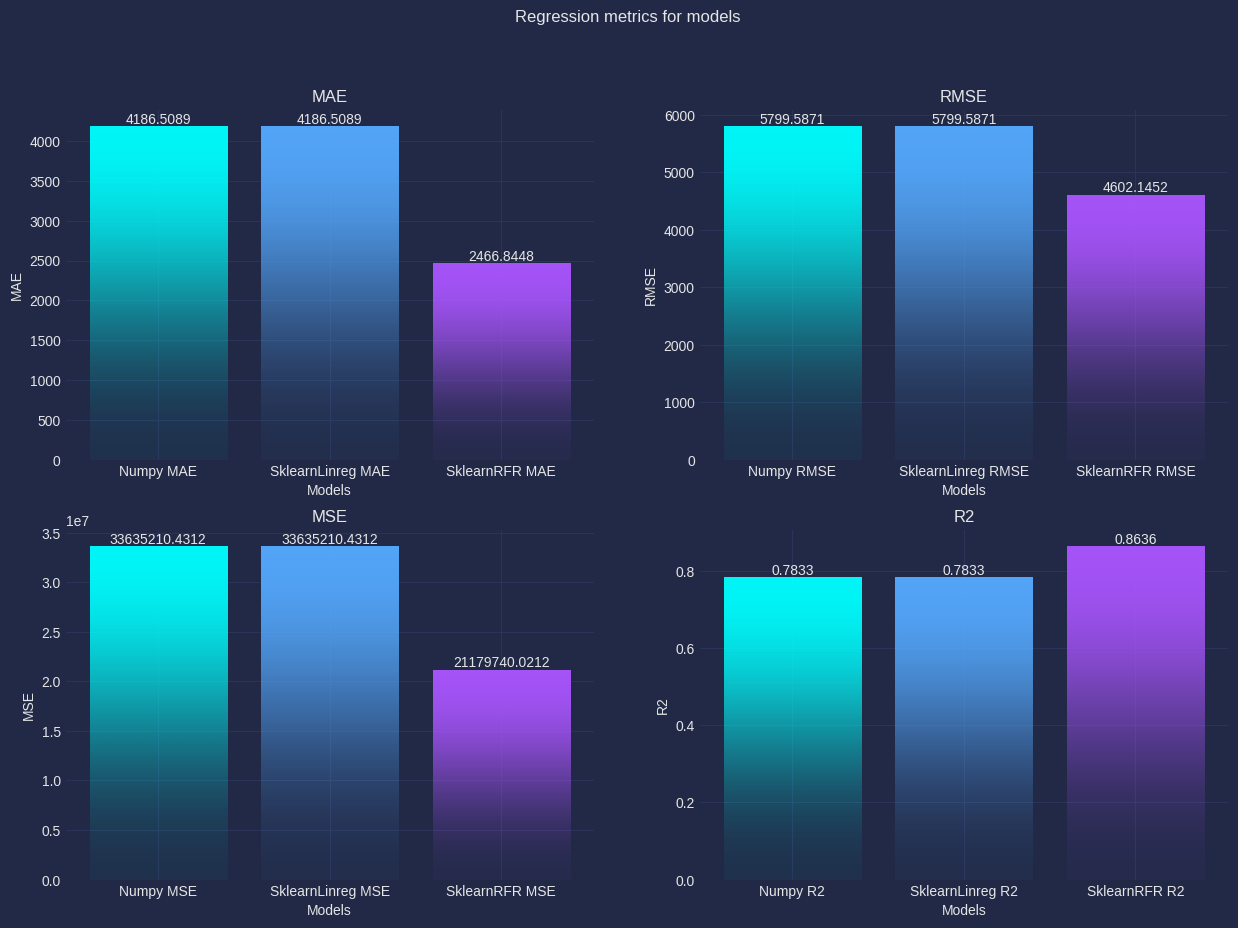

In [20]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
fig.suptitle(f'Regression metrics for models')

for i, cm in enumerate(combined_metrics):
    axes = ax[i % 2, i // 2]
    axes.set_title(cm[0])
    axes.set_ylabel(cm[0])
    axes.set_xlabel('Models')
    height = [h[0] for h in cm[1:]]
    width = [w[1] for w in cm[1:]]
    bars = axes.bar(height, width, color=colors)
    axes.bar_label(bars, fmt='%.4f')
    mplcyberpunk.add_bar_gradient(bars=bars, ax=axes)

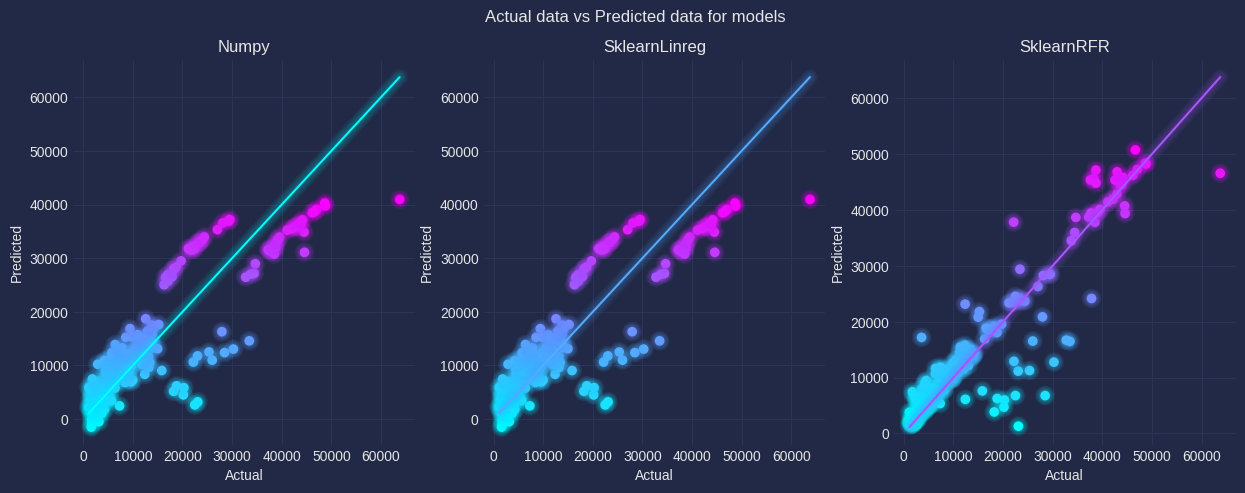

In [21]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
fig.suptitle(f'Actual data vs Predicted data for models')

for i, ca in enumerate(combined_preds):
    axes = ax[i]
    plt.sca(axes)
    axes.set_title(ca[0])
    axes.set_xlabel('Actual')
    axes.set_ylabel('Predicted')
    axes.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color=ca[-1])
    axes.scatter(y_test, ca[1], c=ca[1])
    mplcyberpunk.make_lines_glow(ax=axes)
    mplcyberpunk.make_scatter_glow(ax=axes, alpha=0.5)

As we can see from the metrics, the Numpy and Sklearn linear regression model have the same values for each metric and have identical plots for the Actual data vs Predicted data plot. The Random Forest Regressor performs better than both the models as expected, as linear regression is a relatively simple model while Random Forest Regressor is a complex model.

#### Conclusion

Linear regression is a staple in machine learning and is still widely used today for many applications. I thank you for reading this notebook and if any information presented here is inaccurate or misrepresented, please let me know in the comments. Thank you and have a great day.